In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt # for making figures
%matplotlib inline

In [9]:
# Let's repeat what we did in the last one

In [2]:
# read in all the words
words = open('names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [3]:
len(words)

32033

In [4]:
# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)
print(itos)
print(vocab_size)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


In [5]:
# build the dataset
block_size = 3 # context length: how many characters do we take to predict the next one?

def build_dataset(words):  
  X, Y = [], []
  
  for w in words:
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr,  Ytr  = build_dataset(words[:n1])     # 80%
Xdev, Ydev = build_dataset(words[n1:n2])   # 10%
Xte,  Yte  = build_dataset(words[n2:])     # 10%

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [8]:
# MLP revisited
n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 200 # the number of neurons in the hidden layer of the MLP

g = torch.Generator().manual_seed(2147483647) # for reproducibility
C  = torch.randn((vocab_size, n_embd),            generator=g)
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g)
b1 = torch.randn(n_hidden,                        generator=g)
W2 = torch.randn((n_hidden, vocab_size),          generator=g)
b2 = torch.randn(vocab_size,                      generator=g)

parameters = [C, W1, W2, b2]
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
  p.requires_grad = True

11697


In [10]:
# same optimization as last time
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):

    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix]  # batch X, Y

    # forward pass
    emb = C[Xb]  # embed the characters into vectors
    embcat = emb.view(emb.shape[0], -1)  # concatenate the vectors
    hpreact = embcat @ W1 + b1  # hidden layer pre-activation
    h = torch.tanh(hpreact)  # hidden layer
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Yb)  # loss function

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = 0.1 if i < 100000 else 0.01  # step learning rate decay
    for p in parameters:
        p.data += -lr * p.grad

    # track stats
    if i % 10000 == 0:  # print every once in a while
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())

      0/ 200000: 27.8817
  10000/ 200000: 2.6357
  20000/ 200000: 2.5702
  30000/ 200000: 2.9245
  40000/ 200000: 2.1703
  50000/ 200000: 2.6686
  60000/ 200000: 2.4431
  70000/ 200000: 1.9731
  80000/ 200000: 2.2433
  90000/ 200000: 2.1883
 100000/ 200000: 1.9907
 110000/ 200000: 2.3453
 120000/ 200000: 1.8483
 130000/ 200000: 2.4617
 140000/ 200000: 2.3216
 150000/ 200000: 2.0614
 160000/ 200000: 2.0288
 170000/ 200000: 1.8232
 180000/ 200000: 2.1239
 190000/ 200000: 1.8874


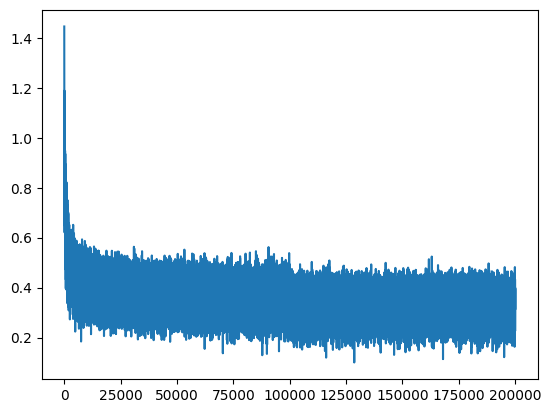

In [11]:
plt.plot(lossi)

In [12]:
@torch.no_grad()  # this decorator disables gradient tracking for any tensors getting created in this method
def split_loss(split):
    x, y = {
        'train': (Xtr, Ytr),
        'val': (Xdev, Ydev),
        'test': (Xte, Yte),
    }[split]
    emb = C[x]  # (N, block_size, n_embd)
    embcat = emb.view(emb.shape[0], -1)  # concat into (N, block_size * n_embd)
    h = torch.tanh(embcat @ W1 + b1)  # (N, n_hidden)
    logits = h @ W2 + b2  # (N, vocab_size)
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())

split_loss('train')
split_loss('val')

train 2.125903606414795
val 2.1684553623199463


In [13]:
# sample from the model
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):

    out = []
    context = [0] * block_size  # initialize with all ...
    while True:
        # forward pass the neural net
        emb = C[torch.tensor([context])]  # (1, block_size, n_embd)
        h = torch.tanh(emb.view(1, -1) @ W1 + b1)
        logits = h @ W2 + b2
        probs = F.softmax(logits, dim=1)
        # sample from the distribution
        ix = torch.multinomial(probs, num_samples=1, generator=g).item()
        # shift the context window and track the samples
        context = context[1:] + [ix]
        out.append(ix)
        # if we sample the special '.' token, break
        if ix == 0:
            break

    print(''.join(itos[i] for i in out))  # decode and print the generated word

carlah.
amoriq.
khy.
mili.
taty.
skanden.
jazhutradherric.
kaqyi.
ner.
kentchaiivia.
leigh.
ham.
joce.
quint.
salin.
alianni.
wazelo.
dearisi.
jace.
pirsa.


In [23]:
'''
Now let's start our scrutinization with out neural net initialization and focus on the initial loss
In neural network, we usually have a rough estimation of what the initial loss should be which depends on the loss function and the problem setup
In this case, the obtained initial loss of 27.88 is totally not the expected one. Lets see why.

We have 27 characters, meaning 27 possibilities for the next character and at initialization, we can say the any of those characters
can come up next. So the probablity distribution among them should be uniform, all 27 probabilities should be equal, like
1/27.0 for each character
And the loss is the negative log probability
'''
print(-torch.tensor(1/27.0).log())
'''
which is 3.29 and that is much, much lesser than 27.88
The meaning of this is, at initialization, out neural net produces probabilities which are way off, some chars are more confident, some
are less. The neural net is more confidently wrong.

So if the logits are all zero or same, we would then have uniform prob distribution
'''
# 4-dimensional example of the issue
logits = torch.tensor([0.0, 0.0, 0.0, 0.0])
logits = torch.randn(4) * 10
probs = torch.softmax(logits, dim=0)
loss = -probs[2].log()  # index 2 is the actual label
logits, probs, loss


tensor(3.2958)


(tensor([ 12.1997,  -7.7441, -13.2151,   0.4654]),
 tensor([9.9999e-01, 2.1802e-09, 9.1725e-12, 8.0143e-06]),
 tensor(25.4148))

In [25]:
'''
Our logits are derived from h @ W2 + b2
Since we want our logits to be near 0, we don't need to add anything like b2 to it, so lets make b2 0
And lets scale down W2 to 0.01 times
'''
print("Expected loss:", -torch.tensor(1/27.0).log())  # from above

Expected loss: tensor(3.2958)


In [35]:
###########################################
#   First Checkpoint                      #
###########################################

In [29]:
# MLP revisited
n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 200 # the number of neurons in the hidden layer of the MLP

g = torch.Generator().manual_seed(2147483647) # for reproducibility
C  = torch.randn((vocab_size, n_embd),            generator=g)
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g)
b1 = torch.randn(n_hidden,                        generator=g)
W2 = torch.randn((n_hidden, vocab_size),          generator=g) * 0.01
b2 = torch.randn(vocab_size,                      generator=g) * 0

parameters = [C, W1, W2, b2]
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
  p.requires_grad = True

11697


In [30]:
# same optimization as last time
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):

    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix]  # batch X, Y

    # forward pass
    emb = C[Xb]  # embed the characters into vectors
    embcat = emb.view(emb.shape[0], -1)  # concatenate the vectors
    hpreact = embcat @ W1 + b1  # hidden layer pre-activation
    h = torch.tanh(hpreact)  # hidden layer
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Yb)  # loss function

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = 0.1 if i < 100000 else 0.01  # step learning rate decay
    for p in parameters:
        p.data += -lr * p.grad

    # track stats
    if i % 10000 == 0:  # print every once in a while
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())
    # break

      0/ 200000: 3.3221
  10000/ 200000: 2.1877
  20000/ 200000: 2.4270
  30000/ 200000: 2.6032
  40000/ 200000: 2.0712
  50000/ 200000: 2.4562
  60000/ 200000: 2.4073
  70000/ 200000: 2.1389
  80000/ 200000: 2.3659
  90000/ 200000: 2.0872
 100000/ 200000: 1.8262
 110000/ 200000: 2.2224
 120000/ 200000: 1.8486
 130000/ 200000: 2.5117
 140000/ 200000: 2.1848
 150000/ 200000: 2.1080
 160000/ 200000: 1.9327
 170000/ 200000: 1.8609
 180000/ 200000: 2.0279
 190000/ 200000: 1.8962


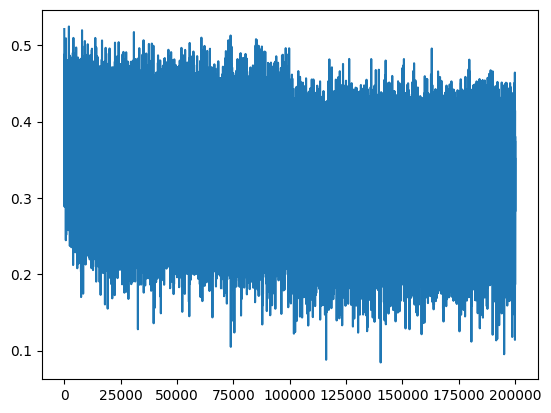

In [31]:
plt.plot(lossi)

In [32]:
@torch.no_grad()  # this decorator disables gradient tracking for any tensors getting created in this method
def split_loss(split):
    x, y = {
        'train': (Xtr, Ytr),
        'val': (Xdev, Ydev),
        'test': (Xte, Yte),
    }[split]
    emb = C[x]  # (N, block_size, n_embd)
    embcat = emb.view(emb.shape[0], -1)  # concat into (N, block_size * n_embd)
    h = torch.tanh(embcat @ W1 + b1)  # (N, n_hidden)
    logits = h @ W2 + b2  # (N, vocab_size)
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())

split_loss('train')
split_loss('val')

train 2.07080340385437
val 2.132983922958374


In [36]:
###########################################
#   Second Checkpoint                     #
###########################################

In [37]:
# Now, lets scrutinize our hidden output, especially tanh
# MLP revisited
n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 200 # the number of neurons in the hidden layer of the MLP

g = torch.Generator().manual_seed(2147483647) # for reproducibility
C  = torch.randn((vocab_size, n_embd),            generator=g)
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g)
b1 = torch.randn(n_hidden,                        generator=g)
W2 = torch.randn((n_hidden, vocab_size),          generator=g) * 0.01
b2 = torch.randn(vocab_size,                      generator=g) * 0

parameters = [C, W1, W2, b2]
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
  p.requires_grad = True

11697


In [38]:
# same optimization as last time
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):

    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix]  # batch X, Y

    # forward pass
    emb = C[Xb]  # embed the characters into vectors
    embcat = emb.view(emb.shape[0], -1)  # concatenate the vectors
    hpreact = embcat @ W1 + b1  # hidden layer pre-activation
    h = torch.tanh(hpreact)  # hidden layer
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Yb)  # loss function

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = 0.1 if i < 100000 else 0.01  # step learning rate decay
    for p in parameters:
        p.data += -lr * p.grad

    # track stats
    if i % 10000 == 0:  # print every once in a while
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())
    break

      0/ 200000: 3.3221


torch.Size([32, 200])
torch.Size([6400])


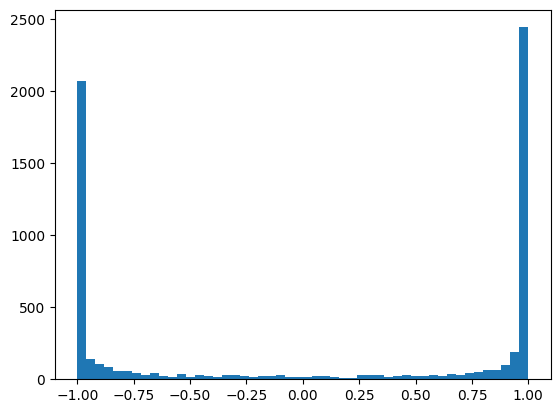

In [47]:
# tanh squashes the output between -1 and 1
print(h.shape)
print(h.view(-1).shape)
plt.hist(h.view(-1).tolist(), 50);  # 50 buckets

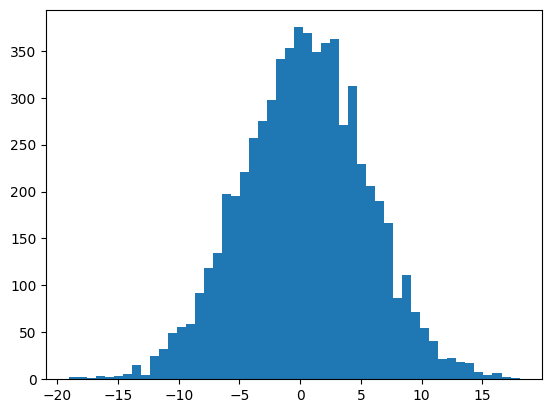

In [52]:
# we see that most of the activations are went to -1 and 1 buckets
# let's see how our hidden pre-activation distribution is like
plt.hist(hpreact.view(-1).tolist(), 50);

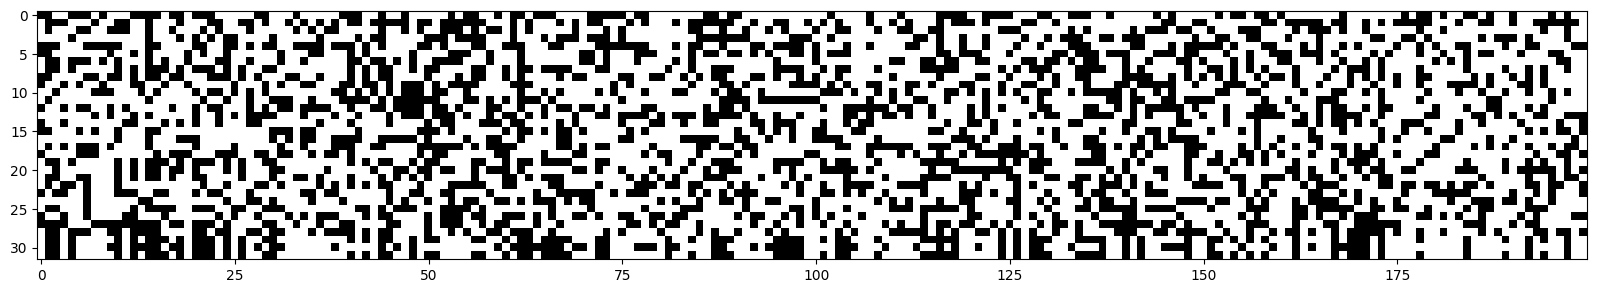

In [53]:
'''
In beginner level of NN, this may not be a real issue, but if we know the nuances in NN
and have a general map of how gradients and activations form in our mind, the above tanh graph is a red alert.
Let's see why.

In our micrograd lecture, we saw tanh.

def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1) / (math.exp(2*x) + 1)  # tanh
        out = Value(t, (self, ), 'tanh')
        def _backward():
            # chain rule in tanh, refer manual gradient settings done below
            self.grad += (1 - t**2) * out.grad
        out._backward = _backward
        return out

In backward pass, let's see what tanh actually does to the gradient passing through it
t -> tanh
=> grad += (1 - t**2) * out.grad
We know the range of t is -1 to 1
t = -1  =>  out.grad * 0 = 0
t = 1   =>  out.grad * 0 = 0
t = 0   =>  out.grad * 1 = out.grad

When the gradient passes backward through tanh, it gets only lowered. The amount it decreases is kind of proportional to how far
you are in the flat tails of tanh.
If tanh is either -1 or 1, the gradient gets destroyed completely in the backward pass.

Let's see another graph
'''
plt.figure(figsize=(20,10))
plt.imshow(h.abs() > 0.99, cmap='gray', interpolation='nearest')

In [54]:
'''
This is a graph of boolean tensors, either 0 or 1 based on the above condition
white - True
black - false
we have 32 examples on y-axis and 200 neurons on x-axis
white - neuron didn't learn from that sample
black - neuron learnt something in that sample

For any neuron among 200 neurons, if the entire column is white, then that particular neuron is called a dead neuron.
It didn't get activated for the entire sample set.
tanh active means that curve before turning into flat tails at -1 and +1. Closer to the flat tails, highly active. above (+-)0.99 - saturated

Similar thing can happen in a ReLU neuron. If all the pre-active computations are negative, then ReLU simply shuts them off and never gets activated.

This might happen while optimization too when by chance, the neuron got too much bigger gradient and the learning rate is large,
the activation gets knocked off to the flatlines and from then on, it becomes a dead neuron. Sort of like a brain damage.

Even though there is no white column in our case, this is still not optimal, especially not in the intial stage
Because of our hpreact is stretched too far between -20 and 20, most of tanh is not activated -> destroys backflow of gradient -> weights get updated less frequently

So we need hpreact to be closer to 0, not stretched out
'''
# MLP revisited
n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 200 # the number of neurons in the hidden layer of the MLP

g = torch.Generator().manual_seed(2147483647) # for reproducibility
C  = torch.randn((vocab_size, n_embd),            generator=g)
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g) * 0.2
b1 = torch.randn(n_hidden,                        generator=g) * 0.01
W2 = torch.randn((n_hidden, vocab_size),          generator=g) * 0.01
b2 = torch.randn(vocab_size,                      generator=g) * 0

parameters = [C, W1, W2, b2]
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
  p.requires_grad = True

11697


In [55]:
# same optimization as last time
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):

    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix]  # batch X, Y

    # forward pass
    emb = C[Xb]  # embed the characters into vectors
    embcat = emb.view(emb.shape[0], -1)  # concatenate the vectors
    hpreact = embcat @ W1 + b1  # hidden layer pre-activation
    h = torch.tanh(hpreact)  # hidden layer
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Yb)  # loss function

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = 0.1 if i < 100000 else 0.01  # step learning rate decay
    for p in parameters:
        p.data += -lr * p.grad

    # track stats
    if i % 10000 == 0:  # print every once in a while
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())
    break

      0/ 200000: 3.3135


torch.Size([32, 200])
torch.Size([6400])


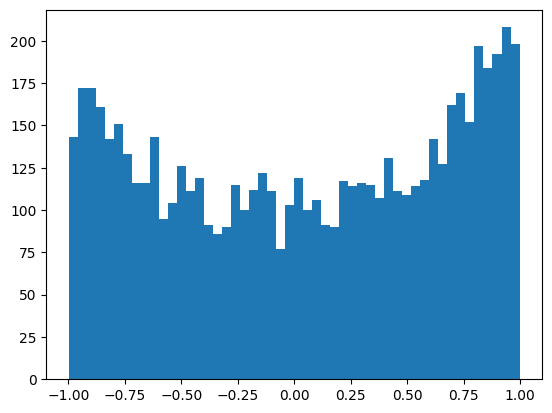

In [56]:
# tanh squashes the output between -1 and 1
print(h.shape)
print(h.view(-1).shape)
plt.hist(h.view(-1).tolist(), 50);  # 50 buckets

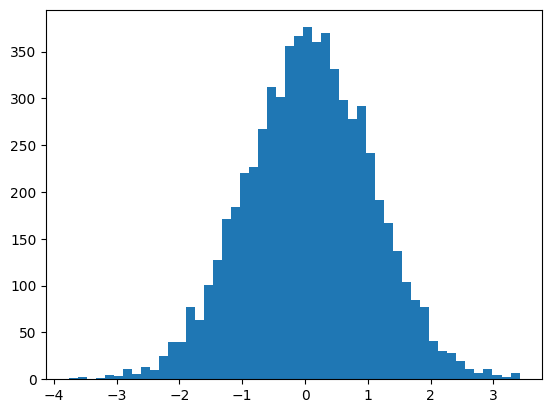

In [57]:
# let's see how our hidden pre-activation distribution is like
plt.hist(hpreact.view(-1).tolist(), 50);

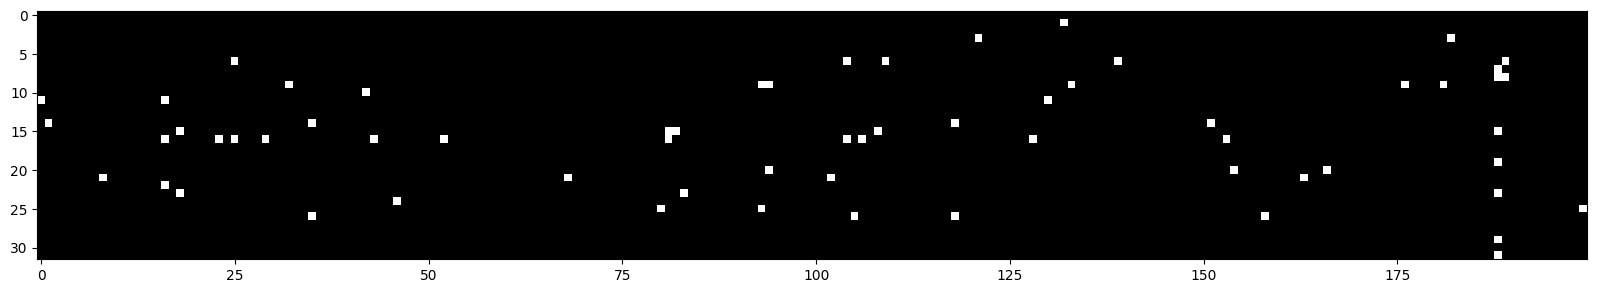

In [59]:
plt.figure(figsize=(20,10))
plt.imshow(h.abs() > 0.99, cmap='gray', interpolation='nearest');

In [60]:
# This looks more optimal now. Let's do actual training now with these configs
# MLP revisited
n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 200 # the number of neurons in the hidden layer of the MLP

g = torch.Generator().manual_seed(2147483647) # for reproducibility
C  = torch.randn((vocab_size, n_embd),            generator=g)
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g) * 0.2
b1 = torch.randn(n_hidden,                        generator=g) * 0.01
W2 = torch.randn((n_hidden, vocab_size),          generator=g) * 0.01
b2 = torch.randn(vocab_size,                      generator=g) * 0

parameters = [C, W1, W2, b2]
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
  p.requires_grad = True

11697


In [61]:
# same optimization as last time
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):

    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix]  # batch X, Y

    # forward pass
    emb = C[Xb]  # embed the characters into vectors
    embcat = emb.view(emb.shape[0], -1)  # concatenate the vectors
    hpreact = embcat @ W1 + b1  # hidden layer pre-activation
    h = torch.tanh(hpreact)  # hidden layer
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Yb)  # loss function

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = 0.1 if i < 100000 else 0.01  # step learning rate decay
    for p in parameters:
        p.data += -lr * p.grad

    # track stats
    if i % 10000 == 0:  # print every once in a while
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())
    # break

      0/ 200000: 3.3135
  10000/ 200000: 2.1715
  20000/ 200000: 2.3240
  30000/ 200000: 2.4010
  40000/ 200000: 1.9887
  50000/ 200000: 2.3029
  60000/ 200000: 2.4564
  70000/ 200000: 2.1249
  80000/ 200000: 2.3069
  90000/ 200000: 2.1057
 100000/ 200000: 1.8948
 110000/ 200000: 2.2326
 120000/ 200000: 1.9659
 130000/ 200000: 2.4410
 140000/ 200000: 2.2106
 150000/ 200000: 2.1795
 160000/ 200000: 1.8383
 170000/ 200000: 1.8131
 180000/ 200000: 1.9572
 190000/ 200000: 1.8002


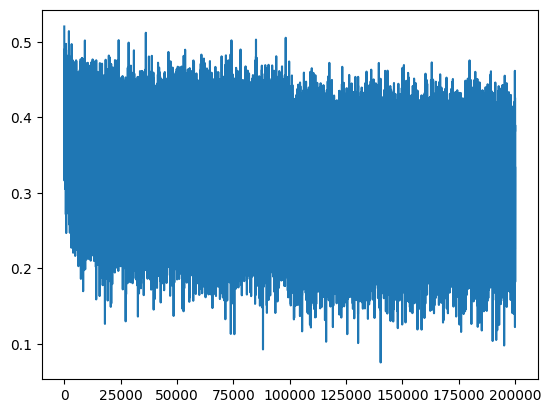

In [62]:
plt.plot(lossi)

In [63]:
@torch.no_grad()  # this decorator disables gradient tracking for any tensors getting created in this method
def split_loss(split):
    x, y = {
        'train': (Xtr, Ytr),
        'val': (Xdev, Ydev),
        'test': (Xte, Yte),
    }[split]
    emb = C[x]  # (N, block_size, n_embd)
    embcat = emb.view(emb.shape[0], -1)  # concat into (N, block_size * n_embd)
    h = torch.tanh(embcat @ W1 + b1)  # (N, n_hidden)
    logits = h @ W2 + b2  # (N, vocab_size)
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())

split_loss('train')
split_loss('val')

train 2.036555528640747
val 2.103057861328125
